In [2]:
import pandas as pd
import glob

In [11]:
base_path = "/green-projects/project-urban_colocation_intelligence/workspace/share/data/"

files = glob.glob(base_path + "2025-03/*/*.gz") + \
        glob.glob(base_path + "2025-04/*/*.gz")

print("Files found:", len(files))
print(files[:5])

Files found: 1837
['/green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00000.gz', '/green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00001.gz', '/green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00002.gz', '/green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00003.gz', '/green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00004.gz']


In [12]:
files_sample = files[:60]

print("Using sample files:", len(files_sample))

Using sample files: 60


In [13]:
from collections import defaultdict
import pandas as pd

cols = ["id", "lat", "lon", "ts", "date", "h3", "type"]

home_counts = defaultdict(int)

for i, f in enumerate(files_sample):
    print(f"Loading {i+1}/{len(files_sample)}:", f)
    
    for chunk in pd.read_csv(
        f,
        sep="\t",             
        names=cols,            
        compression="gzip",
        chunksize=500000
    ):
        # keep only stops
        chunk = chunk[chunk["type"] == "stop"]

        # convert timestamp
        chunk["ts"] = pd.to_datetime(chunk["ts"], unit="s")
        chunk["hour"] = chunk["ts"].dt.hour

        # nighttime filter
        night_chunk = chunk[(chunk["hour"] >= 20) | (chunk["hour"] <= 6)]

        # group
        grouped = night_chunk.groupby(["id", "lat", "lon"]).size()

        # accumulate
        for key, val in grouped.items():
            home_counts[key] += val

Loading 1/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00000.gz
Loading 2/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00001.gz
Loading 3/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00002.gz
Loading 4/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00003.gz
Loading 5/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00004.gz
Loading 6/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00005.gz
Loading 7/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00006.gz
Loading 8/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00007.gz
Loading 9/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03

In [14]:
len(home_counts)

33105395

In [15]:
import pandas as pd

# Step 1: convert dictionary → series (FAST)
s = pd.Series(home_counts)

# Step 2: convert to dataframe
home_df = s.reset_index()
home_df.columns = ["id", "lat", "lon", "count"]

print("Initial size:", len(home_df))

# Step 3: remove noise (VERY IMPORTANT for speed)
home_df = home_df[home_df["count"] >= 2]

print("After filtering:", len(home_df))

# Step 4: sort + get most frequent location per user
home_df = home_df.sort_values(["id", "count"], ascending=[True, False])
home_df = home_df.drop_duplicates("id")

# Step 5: rename
home_df = home_df.rename(columns={
    "lat": "home_lat",
    "lon": "home_lon"
})

# Step 6: keep only needed columns
home_df = home_df[["id", "home_lat", "home_lon"]]

# Step 7: FINAL CHECK (CRITICAL)
print(home_df[["home_lat", "home_lon"]].describe())

Initial size: 33105395
After filtering: 788871
            home_lat       home_lon
count  687092.000000  687092.000000
mean       52.642519      -1.446121
std         1.443287       1.379196
min        49.912600      -7.365660
25%        51.508179      -2.322700
50%        52.393613      -1.423600
75%        53.496900      -0.219900
max        60.457570       1.751024


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Canary Wharf center
cw_lat, cw_lon = 51.505, -0.023

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# distance
home_df["distance_km"] = haversine(
    home_df["home_lat"],
    home_df["home_lon"],
    cw_lat,
    cw_lon
)

In [17]:
np.percentile(home_df["distance_km"], [50, 75, 90])

array([173.54020824, 273.43390828, 389.75438297])

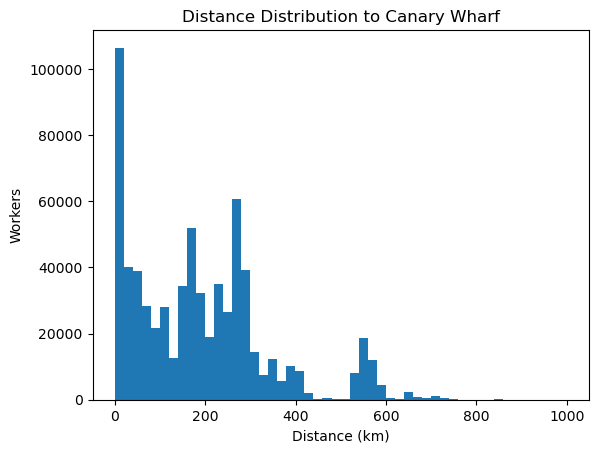

In [11]:
plt.hist(home_df["distance_km"], bins=50)
plt.xlabel("Distance (km)")
plt.ylabel("Workers")
plt.title("Distance Distribution to Canary Wharf")
plt.show()

In [18]:
from collections import defaultdict
import pandas as pd

cols = ["id", "lat", "lon", "ts", "date", "h3", "type"]

home_counts = defaultdict(int)

df_list = []

for i, f in enumerate(files_sample):
    print(f"Reading {i+1}/{len(files_sample)}:", f)

    for chunk in pd.read_csv(
        f,
        sep="\t",
        names=cols,
        compression="gzip",
        chunksize=500000
    ):
        chunk = chunk[chunk["type"] == "stop"]

        # keep only required columns (IMPORTANT for speed)
        df_list.append(chunk[["id", "ts"]])

Reading 1/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00000.gz
Reading 2/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00001.gz
Reading 3/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00002.gz
Reading 4/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00003.gz
Reading 5/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00004.gz
Reading 6/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00005.gz
Reading 7/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00006.gz
Reading 8/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03/3/part-00007.gz
Reading 9/60: /green-projects/project-urban_colocation_intelligence/workspace/share/data/2025-03

In [19]:
df = pd.concat(df_list, ignore_index=True)

print("DF size:", len(df))

DF size: 82102364


In [20]:
np.percentile(home_df["distance_km"], [50, 75, 90])

array([173.54020824, 273.43390828, 389.75438297])

In [33]:
import pandas as pd
import numpy as np

percentiles = np.percentile(home_df["distance_km"], [50, 75, 90])

percentile_table = pd.DataFrame({
    "Metric": [
        "Median (50%)",
        "75th Percentile",
        "90th Percentile"
    ],
    "Distance (km)": percentiles
})

percentile_table

,Metric,Distance (km)
0,Median (50%),20.475712
1,75th Percentile,46.124548
2,90th Percentile,66.665267


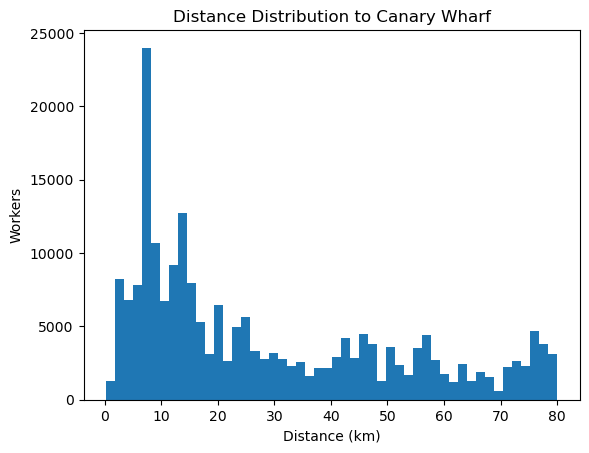

In [23]:
plt.hist(home_df["distance_km"], bins=50)
plt.xlabel("Distance (km)")
plt.ylabel("Workers")
plt.title("Distance Distribution to Canary Wharf")
plt.show()

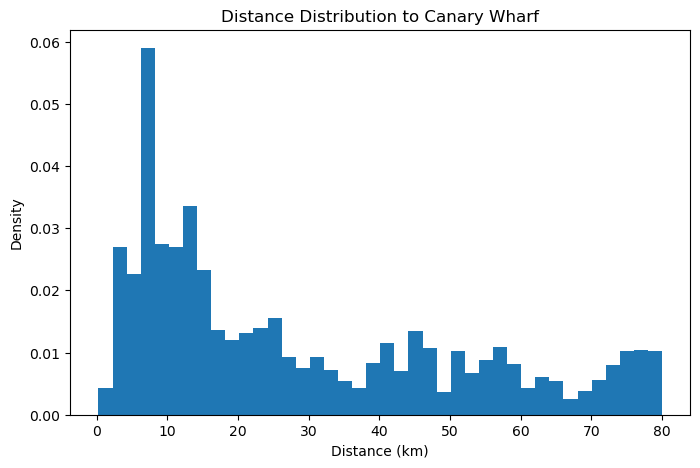

In [32]:
plt.figure(figsize=(8,5))

plt.hist(home_df["distance_km"], bins=40, density=True)

plt.xlabel("Distance (km)")
plt.ylabel("Density")
plt.title("Distance Distribution to Canary Wharf")

plt.show()

In [25]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [29]:
import plotly.express as px

# sample for performance
sample_df = home_df.sample(5000, random_state=42)

# create map
fig = px.scatter_mapbox(
    sample_df,
    lat="home_lat",
    lon="home_lon",
    color="distance_km",
    color_continuous_scale="YlOrRd",
    zoom=9,
    height=600,
    title="Worker Commute Distance to Canary Wharf"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0,"t":40,"l":0,"b":0}
)


fig.write_html("canary_wharf_map.html")

print("Saved as canary_wharf_map.html")

Saved as canary_wharf_map.html


In [30]:
import plotly.express as px

sample_df = home_df.sample(5000, random_state=42)

fig = px.scatter_mapbox(
    sample_df,
    lat="home_lat",
    lon="home_lon",
    color="distance_km",
    color_continuous_scale="YlOrRd",
    zoom=9,
    height=600,
    title="Worker Commute Distance to Canary Wharf"
)

fig.update_layout(
    mapbox_style="carto-positron",  
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.write_html("clean_map.html")

In [21]:
import plotly.express as px
import json

sample_df = home_df.sample(5000, random_state=42)

fig = px.scatter_mapbox(
    sample_df,
    lat="home_lat",
    lon="home_lon",
    color="distance_km",
    color_continuous_scale="YlOrRd",
    zoom=9,
    height=600,
    title="Worker Commute Distance to Canary Wharf"
)

# load boundary
with open("/green-projects/project-urban_colocation_intelligence/workspace/share/data/boundary/canary_wharf.geojson") as f:
    cw_geo = json.load(f)

fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        layers=[
            {
                "source": cw_geo,
                "type": "line",
                "color": "blue",
                "line": {"width": 3},
            }
        ]
    ),
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.write_html("final1_map.html")

In [22]:
print(home_df["distance_km"].min(), home_df["distance_km"].max())

0.2575249094098759 998.0647114841257


In [23]:
home_df = home_df[home_df["distance_km"] <= 80].copy()

print(home_df["distance_km"].min(), home_df["distance_km"].max())

0.2575249094098759 79.99963816600622


In [ ]:
import json

with open("/green-projects/project-urban_colocation_intelligence/workspace/share/data/boundary/canary_wharf.geojson") as f:
    cw_geo = json.load(f)

In [28]:
import plotly.express as px

sample_df = home_df.sample(5000, random_state=42)

fig = px.scatter_mapbox(
    sample_df,
    lat="home_lat",
    lon="home_lon",
    color="distance_km",
    color_continuous_scale="YlOrRd_r", 
    zoom=9,
    height=600,
    title="Commute Distance to Canary Wharf"
)

# load boundary
with open("/green-projects/project-urban_colocation_intelligence/workspace/share/data/boundary/canary_wharf.geojson") as f:
    cw_geo = json.load(f)

fig.update_layout(mapbox_style="carto-positron")

fig.write_html("commute_distance_calculate.html")

In [ ]:
from geopy.distance import geodesic

# Rename columns (if not already done)
home_df = home_df.rename(columns={
    "lat": "home_lat",
    "lon": "home_lon"
})

# Canary Wharf center
CW = (51.5054, -0.0235)

# Compute distance
home_df["distance_km"] = home_df.apply(
    lambda row: geodesic((row["home_lat"], row["home_lon"]), CW).km,
    axis=1
)

In [29]:
import matplotlib.pyplot as plt
from geopy.distance import geodesic

# --- 1. Fix columns ---
home_df = home_df.rename(columns={"lat": "home_lat", "lon": "home_lon"})

# --- 2. Compute distance ---
CW = (51.5054, -0.0235)

home_df["distance_km"] = home_df.apply(
    lambda r: geodesic((r["home_lat"], r["home_lon"]), CW).km,
    axis=1
)

# --- 3. Split groups ---
res_home = home_df[home_df['id'].isin(residents['id'])]
work_home = home_df[home_df['id'].isin(workers['id'])]
leis_home = home_df[home_df['id'].isin(leisure['id'])]

# --- 4. Plot ---
plt.figure(figsize=(10,6))

plt.hist(res_home["distance_km"], bins=50, alpha=0.5, label="Residents")
plt.hist(work_home["distance_km"], bins=50, alpha=0.5, label="Workers")
plt.hist(leis_home["distance_km"], bins=50, alpha=0.5, label="Leisure")

plt.xlabel("Distance from Canary Wharf (km)")
plt.ylabel("Users")
plt.title("Distance from Home by User Type")
plt.legend()

plt.show()

ModuleNotFoundError: No module named 'geopy'

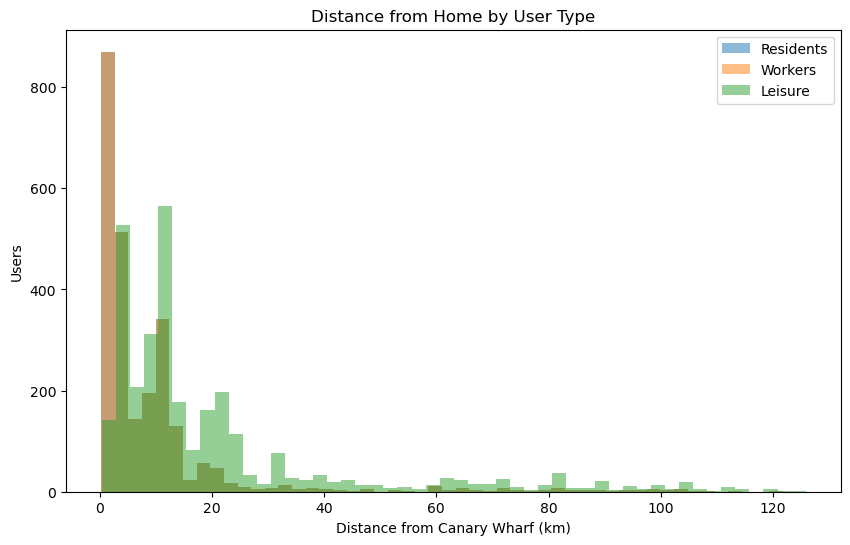

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. LOAD USER GROUP FILES ---
residents = pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/cw_residents_user_ids.csv")
workers = pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/cw_residents_user_ids.csv")
leisure = pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/leisure_user_ids.csv")

# --- 2. FIX COLUMN NAMES (if needed) ---
# (make sure column is called 'id')
residents.columns = ['id']
workers.columns = ['id']
leisure.columns = ['id']

# --- 3. FIX HOME DF ---
home_df = home_df.rename(columns={"lat": "home_lat", "lon": "home_lon"})

# --- 4. FAST DISTANCE ---
CW_LAT = 51.5054
CW_LON = -0.0235

home_df["distance_km"] = np.sqrt(
    (home_df["home_lat"] - CW_LAT)**2 +
    (home_df["home_lon"] - CW_LON)**2
) * 111

# --- 5. SPLIT GROUPS ---
res_home = home_df[home_df['id'].isin(residents['id'])]
work_home = home_df[home_df['id'].isin(workers['id'])]
leis_home = home_df[home_df['id'].isin(leisure['id'])]

# --- 6. PLOT ---
plt.figure(figsize=(10,6))

plt.hist(res_home["distance_km"], bins=50, alpha=0.5, label="Residents")
plt.hist(work_home["distance_km"], bins=50, alpha=0.5, label="Workers")
plt.hist(leis_home["distance_km"], bins=50, alpha=0.5, label="Leisure")

plt.xlabel("Distance from Canary Wharf (km)")
plt.ylabel("Users")
plt.title("Distance from Home by User Type")
plt.legend()

plt.show()

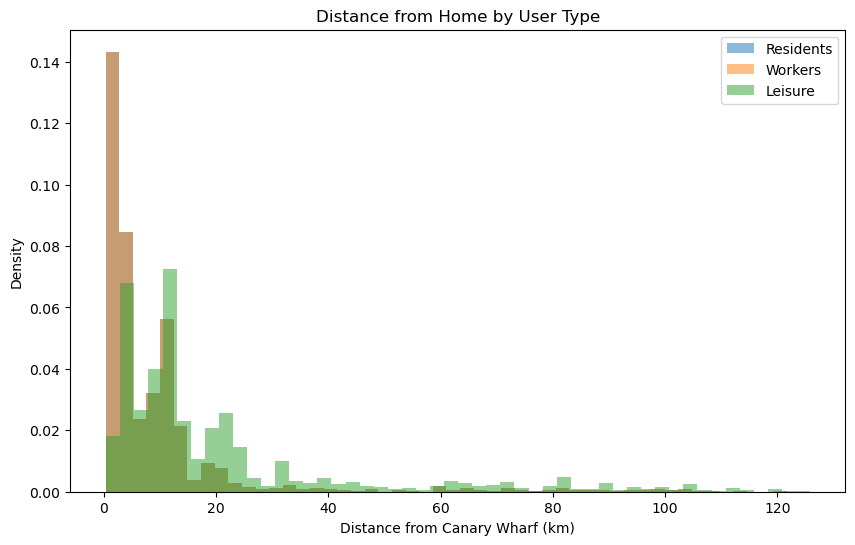

In [32]:
plt.figure(figsize=(10,6))

plt.hist(res_home["distance_km"], bins=50, alpha=0.5, label="Residents", density=True)
plt.hist(work_home["distance_km"], bins=50, alpha=0.5, label="Workers", density=True)
plt.hist(leis_home["distance_km"], bins=50, alpha=0.5, label="Leisure", density=True)

plt.xlabel("Distance from Canary Wharf (km)")
plt.ylabel("Density")
plt.title("Distance from Home by User Type")
plt.legend()

plt.show()

In [33]:
res_home = res_home[res_home["distance_km"] < 50]
work_home = work_home[work_home["distance_km"] < 50]
leis_home = leis_home[leis_home["distance_km"] < 50]

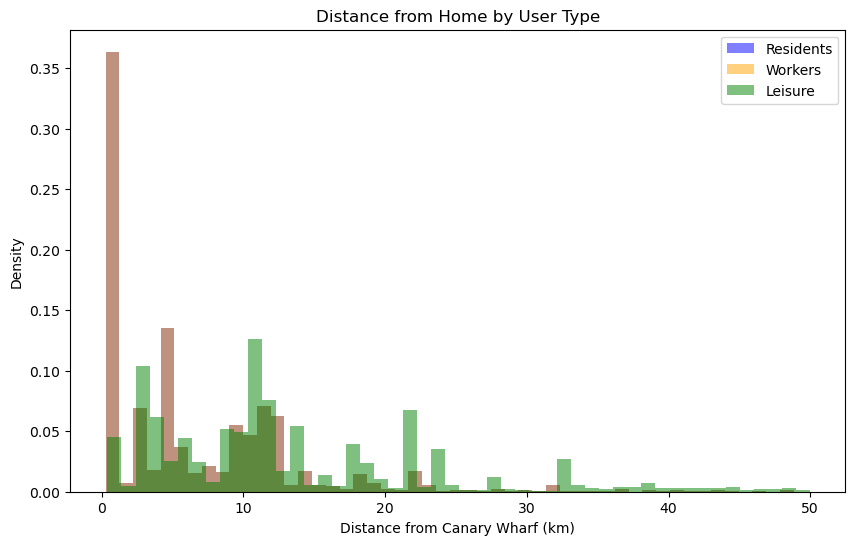

In [34]:
plt.figure(figsize=(10,6))

plt.hist(res_home["distance_km"], bins=50, alpha=0.5,
         label="Residents", density=True, color="blue")

plt.hist(work_home["distance_km"], bins=50, alpha=0.5,
         label="Workers", density=True, color="orange")

plt.hist(leis_home["distance_km"], bins=50, alpha=0.5,
         label="Leisure", density=True, color="green")

plt.xlabel("Distance from Canary Wharf (km)")
plt.ylabel("Density")
plt.title("Distance from Home by User Type")

plt.legend()
plt.show()

In [35]:
import matplotlib.pyplot as plt

# Residents
plt.figure(figsize=(8,5))
plt.hist(resident_home['distance_km'], bins=50)
plt.title("Distance from Canary Wharf (Residents)")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Users")
plt.show()

# Workers
plt.figure(figsize=(8,5))
plt.hist(worker_home['distance_km'], bins=50)
plt.title("Distance from Canary Wharf (Workers)")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Users")
plt.show()

NameError: name 'resident_home' is not defined

<Figure size 800x500 with 0 Axes>

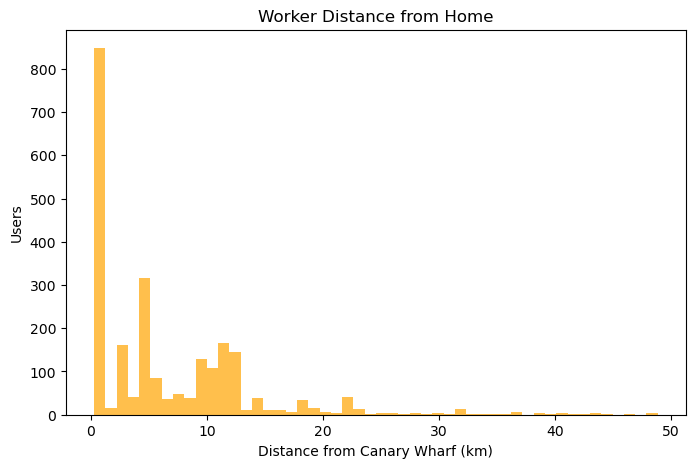

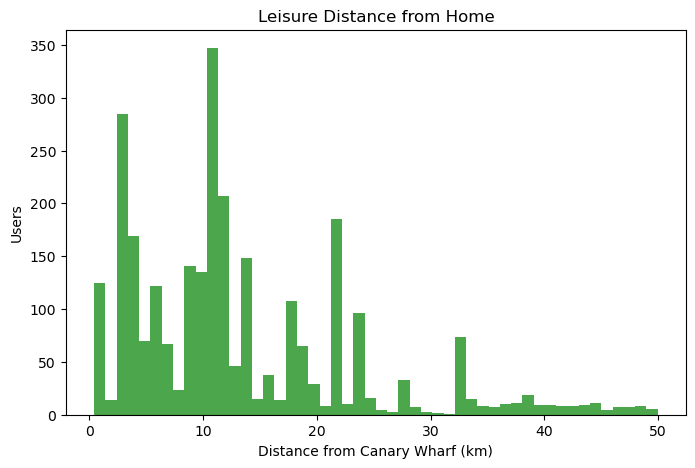

In [36]:
import matplotlib.pyplot as plt

# --- WORKERS ---
plt.figure(figsize=(8,5))
plt.hist(work_home["distance_km"], bins=50, color="orange", alpha=0.7)

plt.xlabel("Distance from Canary Wharf (km)")
plt.ylabel("Users")
plt.title("Worker Distance from Home")

plt.show()


# --- LEISURE ---
plt.figure(figsize=(8,5))
plt.hist(leis_home["distance_km"], bins=50, color="green", alpha=0.7)

plt.xlabel("Distance from Canary Wharf (km)")
plt.ylabel("Users")
plt.title("Leisure Distance from Home")

plt.show()

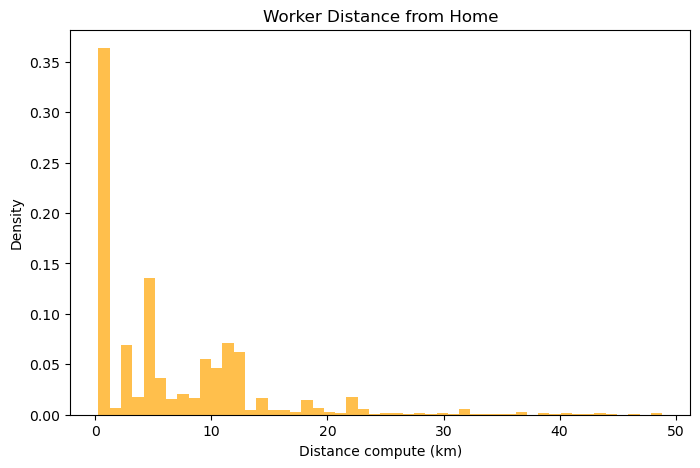

In [39]:
plt.figure(figsize=(8,5))

plt.hist(work_home["distance_km"], bins=50,
         color="orange", alpha=0.7, density=True)

plt.xlabel("Distance compute (km)")
plt.ylabel("Density")
plt.title("Worker Distance from Home")

plt.show()

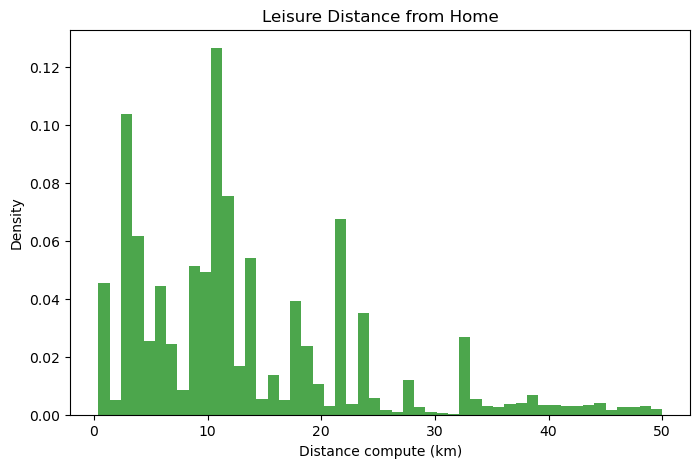

In [40]:
plt.figure(figsize=(8,5))

plt.hist(leis_home["distance_km"], bins=50,
         color="green", alpha=0.7, density=True)

plt.xlabel("Distance compute (km)")
plt.ylabel("Density")
plt.title("Leisure Distance from Home")

plt.show()